**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Bonus Chapter (CI Test Flakiness)](05_bonus_real_world_bayesian_flakiness.ipynb) | **Sheet 6: Calibrating Memory Decay ($\gamma$)**

---


# Sheet 6: Calibrating Memory Decay ($\gamma$) in Dynamic Bayesian Filters
### *From Half-Life and Steady-State Effective Sample Size to Empirical Backtesting in Non-Stationary Environments*

In **Bonus Sheet 5**, we encountered the fading-memory update rule for continuous test flakiness monitoring:

$$\alpha_{t+1} = \gamma \cdot \alpha_t + \text{Failures}_{t+1}$$
$$\beta_{t+1} = \gamma \cdot \beta_t + \text{Passes}_{t+1}$$

where $\gamma \in (0, 1)$ is the **memory decay factor** (or discount factor).

While adding $\gamma$ seems mathematically simple, **deciding on the exact value of $\gamma$** is one of the most critical engineering choices in applied Bayesian statistics. Set $\gamma$ too low, and your model overreacts wildly to short-term noise; set it too high, and your model suffers from stubborn cognitive inertia, trapping fixed tests in quarantine.

In this masterclass sheet, we unpack the mathematical and empirical frameworks used by production reliability and data science teams to calibrate $\gamma$.

---

## Table of Contents
1. **Part 1: The Non-Stationary Dilemma & The Rigidity Trap**
2. **Part 2: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)**
3. **Part 3: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)**
4. **Part 4: Calibration Method 3 — The Responsiveness vs. False-Alarm Trade-off (SLA Calibration)**
5. **Part 5: Calibration Method 4 — Empirical Backtesting & Score Optimization**
6. **Part 6: Advanced Architecture — Event-Triggered & Adaptive Decay**
7. **Part 7: Production Cheat Sheet & Hands-On Exercises**


## Part 1: The Non-Stationary Dilemma & The Rigidity Trap

Standard Bayesian updating assumes the data-generating process is **stationary** (the true underlying parameter $\theta$ is constant over time).

Under stationary Bayes ($\gamma = 1$):
$$\alpha_t = \alpha_0 + \sum_{i=1}^t k_i, \qquad \beta_t = \beta_0 + \sum_{i=1}^t (n_i - k_i)$$

### The Rigidity Trap (Infinite Certainty)
As $t \to \infty$, the total pseudo-count $S_t = \alpha_t + \beta_t \to \infty$.
Recall the variance of a $\text{Beta}(\alpha, \beta)$ distribution:
$$\text{Var}[\theta] = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)} \approx \frac{\hat{\theta}(1 - \hat{\theta})}{S_t}$$

As $S_t$ climbs into thousands or tens of thousands:
1. The posterior variance contracts to near **zero**.
2. The posterior distribution becomes an **infinitely rigid, immovable spike**.
3. If an engineer fixes the bug on Day 100, the new stream of 100 passes has virtually **zero impact** against the accumulated historical weight of 10,000 previous runs.

### The Exponential Forgetting Solution
By introducing $\gamma \in (0, 1)$, past evidence is exponentially discounted. An observation collected $\tau$ time steps ago carries weight:
$$w(\tau) = \gamma^\tau$$

This prevents $S_t$ from growing without bound, enforcing a finite **information horizon**.


## Part 2: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)

The most intuitive way for engineering teams to reason about $\gamma$ is in terms of **temporal half-life** ($t_{1/2}$):
> *"After how many days (or CI runs) should historical evidence lose half of its statistical influence?"*

### Mathematical Derivation
Since evidence decays by a factor of $\gamma$ per time step, after $t_{1/2}$ steps the remaining weight is $0.5$:
$$\gamma^{t_{1/2}} = 0.5$$

Taking the natural logarithm of both sides:
$$t_{1/2} \cdot \ln(\gamma) = \ln(0.5) = -\ln(2)$$

$$t_{1/2} = \frac{-\ln(2)}{\ln(\gamma)} = \frac{\ln(0.5)}{\ln(\gamma)}$$

Using the first-order Taylor expansion $\ln(\gamma) \approx -(1 - \gamma)$ for $\gamma \approx 1$:
$$t_{1/2} \approx \frac{0.6931}{1 - \gamma}$$

### Inverting to Solve for $\gamma$:
Given a desired half-life in days $t_{1/2}$ (e.g., matching a sprint cadence):
$$\gamma = \exp\left(-\frac{\ln 2}{t_{1/2}}\right) = 2^{-1 / t_{1/2}} \approx 1 - \frac{0.6931}{t_{1/2}}$$

Let's compute and visualize weight decay trajectories across time for common choices of $\gamma$.


=== Memory Half-Life for Different Gamma Values ===
Gamma = 0.80  -->  Daily Decay: 20.0%  -->  Half-Life:   3.1 days
Gamma = 0.88  -->  Daily Decay: 12.0%  -->  Half-Life:   5.4 days
Gamma = 0.92  -->  Daily Decay:  8.0%  -->  Half-Life:   8.3 days
Gamma = 0.95  -->  Daily Decay:  5.0%  -->  Half-Life:  13.5 days
Gamma = 0.98  -->  Daily Decay:  2.0%  -->  Half-Life:  34.3 days


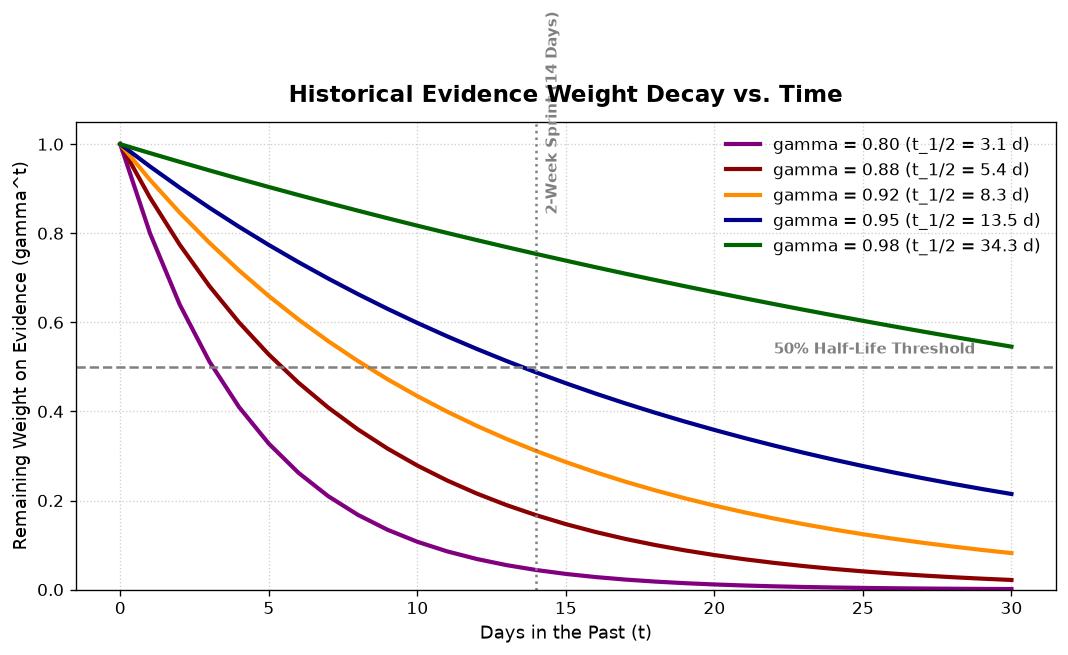

In [1]:
# Calibration Method 1: Half-Life Analysis
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

gammas = np.array([0.80, 0.88, 0.92, 0.95, 0.98])
half_lives = np.log(0.5) / np.log(gammas)

print("=== Memory Half-Life for Different Gamma Values ===")
for g, hl in zip(gammas, half_lives):
    print(f"Gamma = {g:.2f}  -->  Daily Decay: {100 * (1 - g):4.1f}%  -->  Half-Life: {hl:5.1f} days")

# Plot Exponential Weight Decay Curves Over 30 Days
days = np.arange(31)
colors = ["purple", "darkred", "darkorange", "darkblue", "darkgreen"]

plt.figure(figsize=(9, 5.5), dpi=120)
for i, g in enumerate(gammas):
    plt.plot(days, g**days, color=colors[i], linewidth=2.5, label=f"gamma = {g:.2f} (t_1/2 = {half_lives[i]:.1f} d)")

plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
plt.text(22, 0.53, "50% Half-Life Threshold", color='gray', fontsize=9, fontweight='bold')

plt.axvline(14, color='gray', linestyle=':', linewidth=1.5)
plt.text(14.3, 0.85, "2-Week Sprint (14 Days)", color='gray', rotation=90, fontsize=9, fontweight='bold')

plt.title("Historical Evidence Weight Decay vs. Time", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Days in the Past (t)", fontsize=11)
plt.ylabel("Remaining Weight on Evidence (gamma^t)", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## Part 3: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)

A critical property of the discounted Beta filter is that **the total pseudo-count cannot grow to infinity**. It reaches a mathematical ceiling known as the **Steady-State Effective Sample Size** ($N_{\text{eff}}$).

### Derivation
Suppose the CI pipeline runs a test $N$ times each day with memory decay $\gamma$.
The total accumulated pseudo-count at day $T$ is:
$$S_T = N + \gamma N + \gamma^2 N + \dots + \gamma^{T-1} N = N \sum_{k=0}^{T-1} \gamma^k$$

As $T \to \infty$, this infinite geometric series converges to:
$$N_{\text{eff}} = \lim_{T \to \infty} S_T = \frac{N}{1 - \gamma}$$

### Why This Matters for Precision:
Because the effective sample size is bounded by $N_{\text{eff}}$, **your posterior confidence is bounded**.
- The standard deviation of your flakiness estimate will never be smaller than:
  $$\text{SD}_{\text{min}} \approx \sqrt{\frac{\bar{\theta}(1 - \bar{\theta})}{N_{\text{eff}}}} = \sqrt{\frac{\bar{\theta}(1 - \bar{\theta})(1 - \gamma)}{N}}$$

### The Inverted Design Equation:
If your statistics or QA team mandates that the flakiness rate must reflect the confidence of at least $N_{\text{target}}$ test executions:
$$\gamma = 1 - \frac{N_{\text{daily}}}{N_{\text{target}}}$$

Let's simulate the accumulation of effective sample size over 60 days.


=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===
Gamma = 0.80  -->  Max Information Horizon:  100 equivalent test runs
Gamma = 0.88  -->  Max Information Horizon:  167 equivalent test runs
Gamma = 0.92  -->  Max Information Horizon:  250 equivalent test runs
Gamma = 0.95  -->  Max Information Horizon:  400 equivalent test runs
Gamma = 0.98  -->  Max Information Horizon: 1000 equivalent test runs


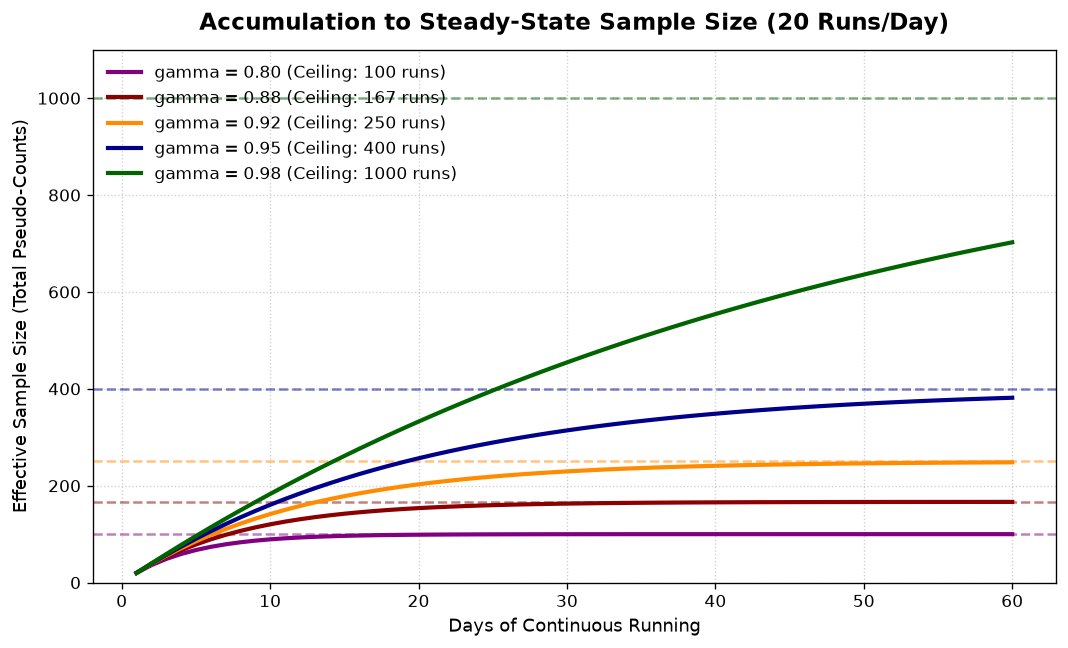

In [2]:
# Calibration Method 2: Effective Sample Size Accumulation
N_daily = 20  # 20 CI runs per day
days = np.arange(1, 61)

# Theoretical ceilings
N_eff_ceilings = N_daily / (1 - gammas)

print("=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===")
for g, ceil in zip(gammas, N_eff_ceilings):
    print(f"Gamma = {g:.2f}  -->  Max Information Horizon: {ceil:4.0f} equivalent test runs")

# Simulate accumulation trajectory: S_T = N * (1 - gamma^T) / (1 - gamma)
plt.figure(figsize=(9, 5.5), dpi=120)
for i, g in enumerate(gammas):
    s_t = N_daily * (1 - g**days) / (1 - g)
    plt.plot(days, s_t, color=colors[i], linewidth=2.5, label=f"gamma = {g:.2f} (Ceiling: {int(round(N_eff_ceilings[i]))} runs)")
    plt.axhline(N_eff_ceilings[i], color=colors[i], linestyle='--', alpha=0.5)

plt.title("Accumulation to Steady-State Sample Size (20 Runs/Day)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Days of Continuous Running", fontsize=11)
plt.ylabel("Effective Sample Size (Total Pseudo-Counts)", fontsize=11)
plt.ylim(0, 1100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## Part 4: Calibration Method 3 — Responsiveness vs. False Alarm Trade-off

The choice of $\gamma$ dictates an inevitable engineering tension:
1. **Low $\gamma$ (High Responsiveness, Poor Specificity)**:
   - Recovers rapidly after bug fixes.
   - High variance: short strings of bad luck (e.g., 2 network timeouts in 10 runs) cause posterior spikes, triggering **false positive quarantines**.
2. **High $\gamma$ (High Stability, Poor Sensitivity)**:
   - Highly resistant to noisy one-off spikes.
   - Low agility: once quarantined, it takes weeks of clean passes to burn off historical penalty, incurring **developer friction**.

### Live 30-Day Pipeline Simulation
Let's simulate a test with 3 distinct lifecycle phases:
- **Days 1 to 10 (Healthy Baseline)**: True flakiness $\theta^* = 1\%$.
- **Days 11 to 14 (Flaky Bug Introduced)**: A race condition pushes true flakiness to $\theta^* = 25\%$.
- **Days 15 to 30 (Bug Fixed)**: The PR merges; true flakiness drops to $\theta^* = 0\%$.

We test 3 candidate configurations:
- **Hyper-reactive**: $\gamma = 0.80$
- **Balanced (Masterclass Recommendation)**: $\gamma = 0.92$
- **Sluggish**: $\gamma = 0.98$

Quarantine Rule: Flag if Upper 95% Credible Interval bound $> 5\%$.


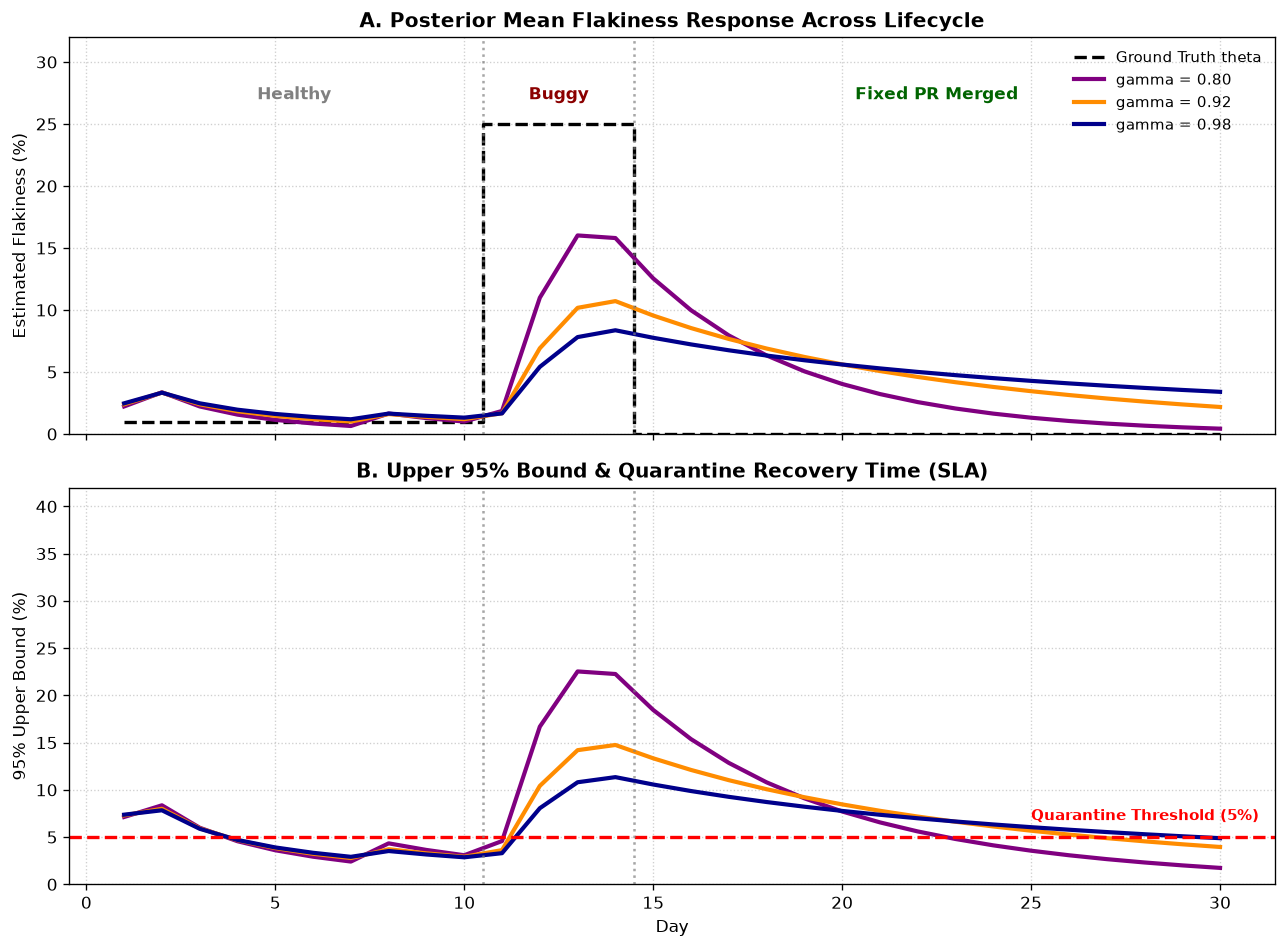

=== Quarantine Recovery Days (Post-Fix on Day 14) ===
Gamma = 0.80  -->  De-quarantined on Day 23 (9 days after bug fix)
Gamma = 0.92  -->  De-quarantined on Day 27 (13 days after bug fix)
Gamma = 0.98  -->  De-quarantined on Day 30 (16 days after bug fix)


In [3]:
# Calibration Method 3: Lifecycle Simulation
np.random.seed(42)

days_total = 30
runs_per_day = 20

# Ground-truth flakiness profile
true_theta = np.array([0.01]*10 + [0.25]*4 + [0.00]*16)

# Simulate synthetic failures from Binomial(runs_per_day, true_theta)
daily_failures = np.random.binomial(runs_per_day, true_theta)

test_gammas = [0.80, 0.92, 0.98]
sim_colors = ["purple", "darkorange", "darkblue"]

results_mean = np.zeros((days_total, len(test_gammas)))
results_q95 = np.zeros((days_total, len(test_gammas)))

for g_idx, g in enumerate(test_gammas):
    # Initialize with uninformative weak prior Beta(1, 19) (mean = 5%)
    a = 1.0
    b = 19.0
    
    for d in range(days_total):
        # Fading memory update
        a = g * a + daily_failures[d]
        b = g * b + (runs_per_day - daily_failures[d])
        
        results_mean[d, g_idx] = 100 * (a / (a + b))
        results_q95[d, g_idx] = 100 * stats.beta.ppf(0.95, a, b)

# Plotting Lifecycle Simulation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), dpi=120, sharex=True)
days_axis = np.arange(1, days_total + 1)

# Panel A: Posterior Mean
ax1.step(days_axis, 100 * true_theta, where='mid', color='black', linestyle='--', linewidth=2, label='Ground Truth theta')
for g_idx, g in enumerate(test_gammas):
    ax1.plot(days_axis, results_mean[:, g_idx], color=sim_colors[g_idx], linewidth=2.5, label=f"gamma = {g:.2f}")

ax1.axvline(10.5, color='gray', linestyle=':', alpha=0.7)
ax1.axvline(14.5, color='gray', linestyle=':', alpha=0.7)
ax1.text(5.5, 27, "Healthy", ha='center', color='gray', fontweight='bold')
ax1.text(12.5, 27, "Buggy", ha='center', color='darkred', fontweight='bold')
ax1.text(22.5, 27, "Fixed PR Merged", ha='center', color='darkgreen', fontweight='bold')

ax1.set_title("A. Posterior Mean Flakiness Response Across Lifecycle", fontsize=12, fontweight='bold')
ax1.set_ylabel("Estimated Flakiness (%)", fontsize=10)
ax1.set_ylim(0, 32)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=False, fontsize=9)

# Panel B: Upper 95% Bound (Quarantine Decision Metric)
for g_idx, g in enumerate(test_gammas):
    ax2.plot(days_axis, results_q95[:, g_idx], color=sim_colors[g_idx], linewidth=2.5, label=f"gamma = {g:.2f}")

ax2.axhline(5.0, color='red', linestyle='--', linewidth=2, label='Quarantine Threshold (5%)')
ax2.text(25, 6.8, "Quarantine Threshold (5%)", color='red', fontsize=9, fontweight='bold')
ax2.axvline(10.5, color='gray', linestyle=':', alpha=0.7)
ax2.axvline(14.5, color='gray', linestyle=':', alpha=0.7)

ax2.set_title("B. Upper 95% Bound & Quarantine Recovery Time (SLA)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Day", fontsize=10)
ax2.set_ylabel("95% Upper Bound (%)", fontsize=10)
ax2.set_ylim(0, 42)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Compute exact recovery days (first day after Day 14 where Q95 < 5%)
print("=== Quarantine Recovery Days (Post-Fix on Day 14) ===")
for g_idx, g in enumerate(test_gammas):
    post_fix_q95 = results_q95[14:, g_idx]
    rec_indices = np.where(post_fix_q95 < 5.0)[0]
    if len(rec_indices) > 0:
        rec_day = rec_indices[0] + 1
        print(f"Gamma = {g:.2f}  -->  De-quarantined on Day {14 + rec_day} ({rec_day} days after bug fix)")
    else:
        print(f"Gamma = {g:.2f}  -->  STILL QUARANTINED after {days_total - 14} days!")


## Part 5: Calibration Method 4 — Empirical Backtesting & Score Optimization

When historical test execution logs are available (e.g., thousands of runs over 6 months), data scientists do not guess $\gamma$ — they **fit it by maximizing predictive accuracy**.

### The Pre-quential (One-Step-Ahead) Log Predictive Score
At each day $t$, before observing that day's test failures $k_t$, we make a prediction using our current parameters $(\alpha_{t-1}, \beta_{t-1})$.
The probability of observing $k_t$ failures out of $n_t$ runs follows the **Beta-Binomial compound distribution**:

$$P(k_t \mid n_t, \alpha_{t-1}, \beta_{t-1}) = \binom{n_t}{k_t} \frac{\text{B}(\alpha_{t-1} + k_t, \; \beta_{t-1} + n_t - k_t)}{\text{B}(\alpha_{t-1}, \beta_{t-1})}$$

Taking logs and summing across the entire historical timeline $t = 1, \dots, T$:
$$\mathcal{LL}(\gamma) = \sum_{t=1}^T \ln P\Big(k_t \mid n_t, \alpha_{t-1}(\gamma), \beta_{t-1}(\gamma)\Big)$$

The optimal decay factor $\gamma^*$ is the argmax:
$$\gamma^* = \arg\max_{\gamma} \mathcal{LL}(\gamma)$$

Alternatively, teams evaluate the **Brier Score (Mean Squared Calibration Error)**:
$$\text{Brier}(\gamma) = \frac{1}{T} \sum_{t=1}^T \left(\frac{k_t}{n_t} - \frac{\alpha_{t-1}(\gamma)}{\alpha_{t-1}(\gamma) + \beta_{t-1}(\gamma)}\right)^2$$

Let's write an optimizer in Python to find $\gamma^*$ via grid search over historical data.


=== Backtesting Optimization Results ===
Optimal Gamma (Max Log-Likelihood) : 0.70 (Score: -40.45)
Optimal Gamma (Min Brier Score)    : 0.70 (Brier: 0.01031)


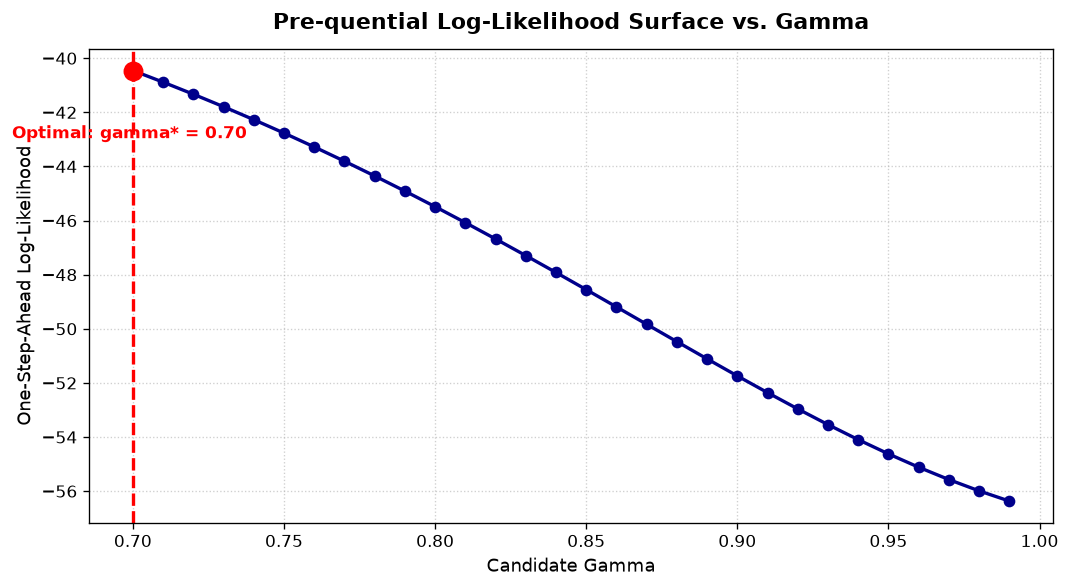

In [4]:
# Calibration Method 4: Backtesting Optimizer
import scipy.special as sp

# Beta-Binomial log-likelihood function
def log_beta_binom(k, n, a, b):
    # log [ n! / (k! (n-k)!) * Beta(a+k, b+n-k) / Beta(a, b) ]
    log_comb = sp.gammaln(n + 1) - sp.gammaln(k + 1) - sp.gammaln(n - k + 1)
    log_beta_num = sp.betaln(a + k, b + n - k)
    log_beta_den = sp.betaln(a, b)
    return log_comb + log_beta_num - log_beta_den

# Pre-quential Log-Likelihood objective function
def evaluate_gamma(g, k_vec, n_vec, a0=1.0, b0=19.0):
    total_loglik = 0.0
    brier_sum = 0.0
    a = a0
    b = b0
    
    for t in range(len(k_vec)):
        # 1. Evaluate one-step-ahead prediction before updating
        ll = log_beta_binom(k_vec[t], n_vec[t], a, b)
        pred_mean = a / (a + b)
        obs_rate = k_vec[t] / n_vec[t]
        
        total_loglik += ll
        brier_sum += (obs_rate - pred_mean)**2
        
        # 2. Update state with decay g
        a = g * a + k_vec[t]
        b = g * b + (n_vec[t] - k_vec[t])
        
    return total_loglik, brier_sum / len(k_vec)

# Grid Search across gamma in [0.70, 0.99]
gamma_candidates = np.arange(0.70, 0.995, 0.01)
loglik_scores = np.zeros(len(gamma_candidates))
brier_scores = np.zeros(len(gamma_candidates))

n_vec = np.array([runs_per_day] * days_total)
for i, g in enumerate(gamma_candidates):
    ll, br = evaluate_gamma(g, daily_failures, n_vec)
    loglik_scores[i] = ll
    brier_scores[i] = br

best_idx = np.argmax(loglik_scores)
best_gamma = gamma_candidates[best_idx]

print("=== Backtesting Optimization Results ===")
print(f"Optimal Gamma (Max Log-Likelihood) : {best_gamma:.2f} (Score: {loglik_scores[best_idx]:.2f})")
print(f"Optimal Gamma (Min Brier Score)    : {gamma_candidates[np.argmin(brier_scores)]:.2f} (Brier: {np.min(brier_scores):.5f})")

# Plot Objective Function Surface
plt.figure(figsize=(9, 5), dpi=120)
plt.plot(gamma_candidates, loglik_scores, color='darkblue', marker='o', linewidth=2)
plt.axvline(best_gamma, color='red', linestyle='--', linewidth=2)
plt.scatter(best_gamma, loglik_scores[best_idx], color='red', s=120, zorder=5)
plt.text(best_gamma - 0.04, loglik_scores[best_idx] - 2.5, f"Optimal: gamma* = {best_gamma:.2f}", color='red', fontweight='bold')

plt.title("Pre-quential Log-Likelihood Surface vs. Gamma", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Candidate Gamma", fontsize=11)
plt.ylabel("One-Step-Ahead Log-Likelihood", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Part 6: Advanced Architecture — Event-Triggered & Adaptive Decay

In production software engineering, assuming a **constant** $\gamma$ every single day is an oversimplification. Why?

### The Commit / Deploy Discontinuity
Between code commits, a test's environment and binary are stationary $\implies$ Use high $\gamma \approx 0.96$ to accumulate statistical precision.
When a pull request **touches files in the test's dependency graph**:
- The past flakiness history of that test has fundamentally been altered.
- Holding onto past failures after an explicit code modification is irrational.

### Architecture 1: Git-Hooked Event Decay
$$\gamma_t = \begin{cases}
0.30 & \text{if git commit touched test or target module today (Drastic Reset)} \\
0.95 & \text{routine CI day without related code edits (Stationary Drift)}
\end{cases}$$

### Architecture 2: Bayesian Surprisal / Bayes Factor Trigger
If unexpected results occur (e.g., 5 consecutive failures on a test with a 0.1% historical flakiness rate), the **Bayes Factor** against the stationary model spikes:
$$\text{Surprise}_t = -\ln P(k_t \mid n_t, \alpha_{t-1}, \beta_{t-1})$$

When $\text{Surprise}_t$ exceeds a threshold $\tau$, the filter automatically drops $\gamma$ to adaptively accelerate learning of the new regime.


## Part 7: Production Cheat Sheet & Hands-On Exercises

### Summary Calibration Matrix

| Team Cadence / Scenario | Daily Runs ($N$) | Target $N_{\text{eff}}$ | Target Half-Life ($t_{1/2}$) | Recommended $\gamma$ | Rationale |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Continuous Deployment / Trunk** | $50+$ | $500$ | $3\text{--}5$ days | **$0.88\text{--}0.90$** | High throughput gives rapid precision; needs fast un-quarantine |
| **Standard 2-Week Sprints** | $15\text{--}25$ | $250$ | $8\text{--}12$ days | **$0.92\text{--}0.94$** | Balances bug forgiveness with resilience against random flukes |
| **Slow Enterprise / Nightly Suite**| $1\text{--}3$ | $50$ | $20\text{--}30$ days | **$0.96\text{--}0.98$** | Low throughput requires long memory to detect subtle 2% flakiness |
| **Post-Commit Reset Hook** | Any | Reset | Instantaneous | **$0.20\text{--}0.40$** | Explicit architectural signal that previous history is invalid |

---

### 🏋️ Hands-On Challenge Exercises

#### Exercise 1: Closed-Form Quarantine Recovery Calculator
Write an R function `days_to_dequarantine(alpha_init, beta_init, gamma, daily_passes, threshold_q95)` that mathematically steps through consecutive days of 100% passes and returns the exact integer number of days until the upper 95% Credible Interval drops below `threshold_q95`.

#### Exercise 2: Grid Search Over Multiple Tests
Suppose you have a suite of 50 tests with different run frequencies ($N \in [5, 100]$ runs/day). Should they all share the same $\gamma$? Why or why not? *(Hint: Look back at Part 3 and the relationship between $N$ and $N_{\text{eff}}$).*


---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Bonus Chapter (CI Test Flakiness)](05_bonus_real_world_bayesian_flakiness.ipynb) | **Masterclass Complete 🎉**
